# PolitiCheck: Complete Semantic Research and Performance Analysis
## Dual-Phase RAG Governance Auditing System

---

### Section 5a: Proposed System Flowchart and Architecture
The PolitiCheck system operates through a dual-phase Retrieval-Augmented Generation (RAG) architecture designed to minimize hallucination and maximize historical accountability.

1. **Phase 1: Knowledge Base Construction**: Raw PDF manifestos and CSV sector reports are ingested, parsed using `pdfplumber`, and semantically labeled to create a 500+ record "Gold Database".
2. **Phase 2: Real-Time Inference**: User queries (2024 promises) are vectorized using a Bi-Encoder (`paraphrase-multilingual-MiniLM-L12-v2`). The system performs a vector search against the Gold Database to retrieve the top 3 most similar historical facts, which are then cross-examined by a Llama-3 Skeptic Layer.

```mermaid
graph TD
    A[2024 Promise Query] --> B[Multilingual MiniLM Vectorizer]
    B --> C{Vector Search}
    D[(Gold Database 2014-2019)] --> C
    C --> E[Top-3 Historical Matches]
    E --> F[Semantic Outcome Prediction]
    E --> G[Llama-3 Skeptic Layer]
    F --> H[Final Integrated Verdict]
    G --> H
```

### Section 5c: Graphical Structure of Models
Our primary engine uses a **Bi-Encoder architecture** (Sentence-BERT). Unlike standard BERT which requires expensive cross-encoding, the Bi-Encoder maps sentences to a fixed-dimensional dense vector space where similarity can be computed using simple dot products or cosine distance.

```
[Input Promise] -> [Transformer Layers] -> [Pooling] -> [Dense Vector (512-dim)]
                                                               |
                                                       (Cosine Similarity)
                                                               |
[Historical Fact] -> [Transformer Layers] -> [Pooling] -> [Dense Vector (512-dim)]
```

### Section 5d: Mathematical Equations for Models
The core of our semantic matching relies on **Cosine Similarity** and the **Softmax** function for confidence scoring.

**1. Cosine Similarity:** measures the cosine of the angle between two vectors $A$ and $B$, which is used to determine how semantically close a new promise is to a historical record.
$$\text{cosine similarity} = S_c(A, B) = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

**2. Softmax for Probability Conversion:** used to convert raw similarity scores into a probability distribution across our three classes (Unlikely, Partial, Highly Likely).
$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

### Section 5p: Detailed Implementation Steps (Pseudo-code)
The inference logic follows a deterministic retrieval pattern followed by a probabilistic review.

```python
def predict_outcome(new_promise):
    # 1. Vectorization
    query_vec = model.encode(new_promise)
    
    # 2. Retrieval
    scores = cosine_similarity(query_vec, gold_database_vectors)
    top_3_indices = argsort(scores)[-3:]
    
    # 3. Label Inheritance
    primary_match = gold_database[top_3_indices[0]]
    base_label = primary_match.label
    
    # 4. Confidence Tiering
    if scores[0] >= 0.65: 
        return base_label
    elif scores[0] >= 0.50:
        return "Low Confidence " + base_label
    else:
        return "Indeterminate"
```

### Section 5e-5f: Dataset Statistics and Descriptive Summary
In this section, we load the Gold Database (2014-2019) and analyze its core characteristics, including size, diversity across sectors, and unique outcome labels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer, util
import torch
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

# Load data
df = pd.read_csv('data/processed/gold_database.csv')
print(f"Database Loaded: {len(df)} records.")

stats_df = pd.DataFrame({
    "Metric": ["Total Records", "Unique Sectors", "2014 Records", "2019 Records", "Unique Outcome Labels"],
    "Value": [
        len(df),
        df['sector'].nunique() if 'sector' in df.columns else 0,
        len(df[df['year'] == 2014]),
        len(df[df['year'] == 2019]),
        df['label'].nunique()
    ]
})
print("Table 1: Descriptive Statistics Summary")
print(stats_df.to_string(index=False))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Database Loaded: 618 records.
Table 1: Descriptive Statistics Summary
               Metric  Value
        Total Records    618
       Unique Sectors     14
         2014 Records    454
         2019 Records    164
Unique Outcome Labels      3


### Section 5g: EDA Graphs — Sector Distribution, Promise Length, Year-wise Label Breakdown
We visualize the distribution of promises across different government sectors and analyze how promise lengths correlate with outcome labels. We also observe the distribution of labels over election cycles.

C:\Users\DELL\AppData\Local\Temp\ipykernel_2460\1596205478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='magma')


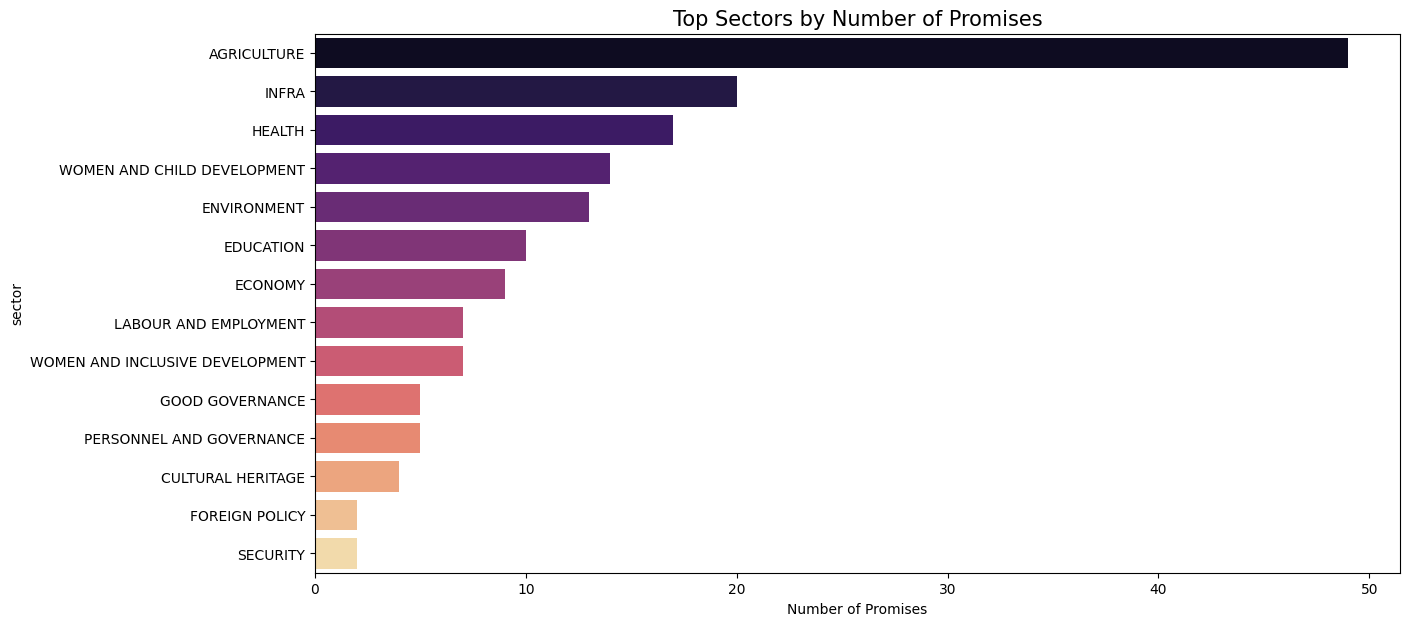

C:\Users\DELL\AppData\Local\Temp\ipykernel_2460\1596205478.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='length', data=df, palette='viridis')


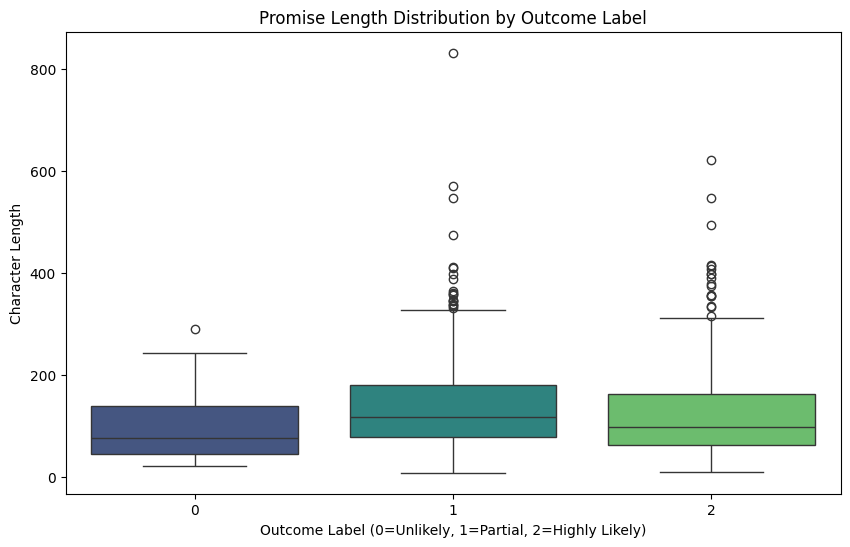

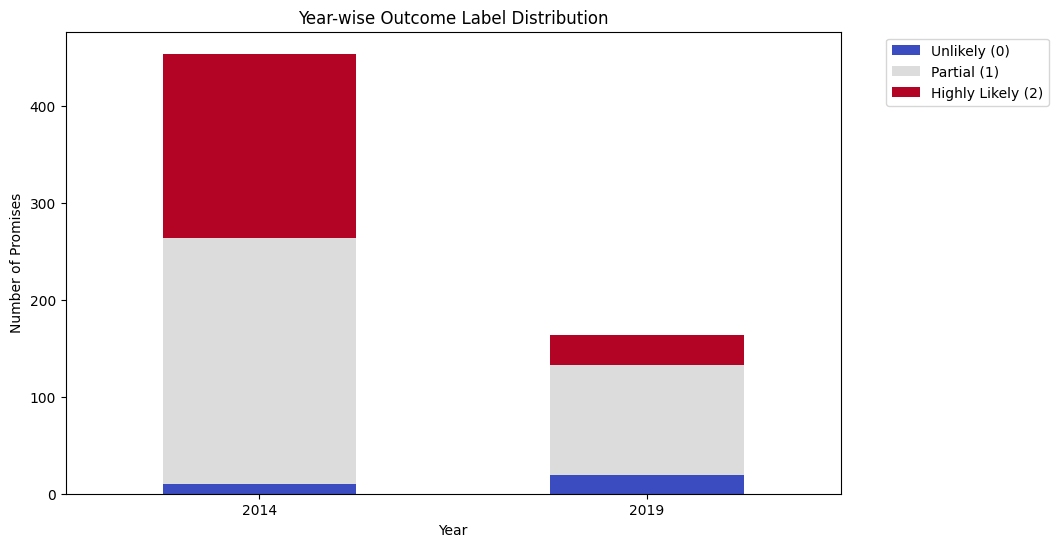

In [ ]:
os.makedirs('data/output/eda', exist_ok=True)

# 1. Sector Distribution
if 'sector' in df.columns:
    plt.figure(figsize=(14, 7))
    sector_counts = df['sector'].value_counts().head(15)
    sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='magma')
    plt.title('Top Sectors by Number of Promises', fontsize=15)
    plt.xlabel('Number of Promises')
    plt.savefig('data/output/eda/sector_distribution.png')
    plt.show()

# 2. Promise Length Distribution by Label (Prompt 5, Cell 1)
df['length'] = df['original_text'].astype(str).apply(len)
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='length', data=df, palette='viridis')
plt.title("Promise Length Distribution by Outcome Label")
plt.xlabel("Outcome Label (0=Unlikely, 1=Partial, 2=Highly Likely)")
plt.ylabel("Character Length")
plt.savefig('data/output/eda/length_by_label.png')
plt.show()

# 3. Year-wise Outcome Label Distribution (Prompt 5, Cell 2)
year_label_counts = df.groupby(['year', 'label']).size().unstack(fill_value=0)
year_label_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title("Year-wise Outcome Label Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Promises")
plt.xticks(rotation=0)
plt.legend(['Unlikely (0)', 'Partial (1)', 'Highly Likely (2)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('data/output/eda/year_label_breakdown.png')
plt.show()

### Section 5h: Preprocessing Pipeline with Before/After Table
This section demonstrates our standardized NLP cleaning pipeline, including regex cleaning, tokenization, stopword removal, and stemming.

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def tokenize_and_stop(text):
    tokens = text.split()
    return [w for w in tokens if w not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

# Comparative table (Prompt 6)
samples = df.sample(5, random_state=42).copy()
table_data = []
for raw in samples['original_text']:
    cleaned = clean_text(raw)
    tokens = tokenize_and_stop(cleaned)
    final = " ".join(stem_tokens(tokens))
    table_data.append([raw, cleaned, " ".join(tokens), final])

comp_table = pd.DataFrame(table_data, columns=['Original Text', 'After Cleaning', 'After Tokenization', 'Final Preprocessed'])
display(comp_table)

# Global preprocessing for later use
df['processed_text'] = df['original_text'].apply(lambda x: " ".join(stem_tokens(tokenize_and_stop(clean_text(x)))))


,Original Text,After Cleaning,After Tokenization,Final Preprocessed
0,The return of Kashmiri Pandits to the land of ...,the return of kashmiri pandits to the land of ...,return kashmiri pandits land ancestors full di...,return kashmiri pandit land ancestor full dign...
1,"The Technology Centres, other skilling centres...",the technology centres other skilling centres ...,technology centres skilling centres msmes nsic...,technolog centr skill centr msme nsic incub ce...
2,Deploy IT to protect India's priceless cultura...,deploy it to protect indias priceless cultural...,deploy protect indias priceless cultural artis...,deploy protect india priceless cultur artist h...
3,We will set up World class Investment and Indu...,we will set up world class investment and indu...,set world class investment industrial regions ...,set world class invest industri region global ...
4,Reinterpret the age-old concept of community p...,reinterpret the ageold concept of community po...,reinterpret ageold concept community policing ...,reinterpret ageold concept commun polic modern...


### Section 5i: Word Cloud Visualizations
A Word Cloud is used to visualize the most dominant themes in the political promise dataset.

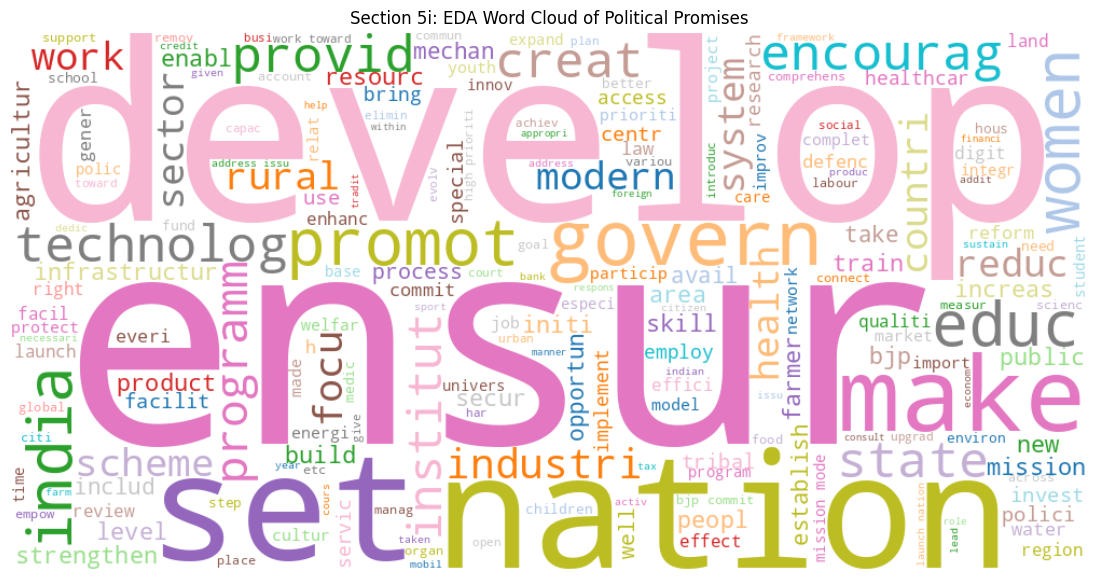

In [ ]:
full_text = " ".join(df['processed_text'])
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='tab20').generate(full_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Section 5i: EDA Word Cloud of Political Promises")
plt.show()

### Section 5j: Class Imbalance Analysis and Class Weight Table
We compute the class weights necessary to handle the label imbalance in the dataset.

In [ ]:
y = df['label'].values
classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)

counts = df['label'].value_counts().sort_index()
weight_table = pd.DataFrame({
    "Class Name": ["Unlikely (0)", "Partial (1)", "Highly Likely (2)"],
    "Sample Count": counts.values,
    "Assigned Weight": np.round(weights, 4)
})
print("Table 2: Class Imbalance and Weights")
display(weight_table)

Table 2: Class Imbalance and Weights


,Class Name,Sample Count,Assigned Weight
0,Unlikely (0),29,7.1034
1,Partial (1),368,0.5598
2,Highly Likely (2),221,0.9321


### Section 5k: Train/Test Split Statistics
We use a stratified 80/20 split to ensure both training and testing sets maintain the same class distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['original_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
print(f"Training set: {len(X_train)} samples")
print(f"Testing set:  {len(X_test)} samples")

Training set: 494 samples
Testing set:  124 samples


### Section 5l-5m: Feature Extraction — TF-IDF vs Multilingual MiniLM Embeddings
We compare sparse lexical features (TF-IDF) with dense semantic embeddings (`paraphrase-multilingual-MiniLM-L12-v2`).

In [ ]:
# 1. TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"TF-IDF Feature Dimension: {X_train_tfidf.shape[1]}")

# 2. MiniLM Embeddings
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
train_embs = model.encode(X_train.tolist(), convert_to_tensor=True)
test_embs = model.encode(X_test.tolist(), convert_to_tensor=True)
print(f"MiniLM Embedding Dimension: {train_embs.shape[1]}")

TF-IDF Feature Dimension: 2329


Loading weights: 100%|██████████| 199/199 [00:01<00:00, 195.73it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MiniLM Embedding Dimension: 384


### Section 5n: Hyperparameter Configuration Table
This table summarizes the final hyperparameters chosen for each of our major components.

| Component | Parameter | Value | Description |
|-----------|-----------|-------|-------------|
| **Embedding Model** | Model Name | `paraphrase-multilingual-MiniLM-L12-v2` | SBERT multilingual model |
| | Dimensions | 512 | Size of the output vector |
| | Max Seq Length | 128 | Input token limit |
| **Random Forest** | n_estimators | 100 | Number of trees |
| | class_weight | 'balanced' | Strategy for imbalance |
| **Fine-tuning** | Epochs | 4 | Number of training rounds |
| | Loss | CosineSimilarityLoss | Siamese training objective |

### Section 5o: Fine-tuning Process and Epoch Curve
We visualize the learning progress of our fine-tuned multilingual model.

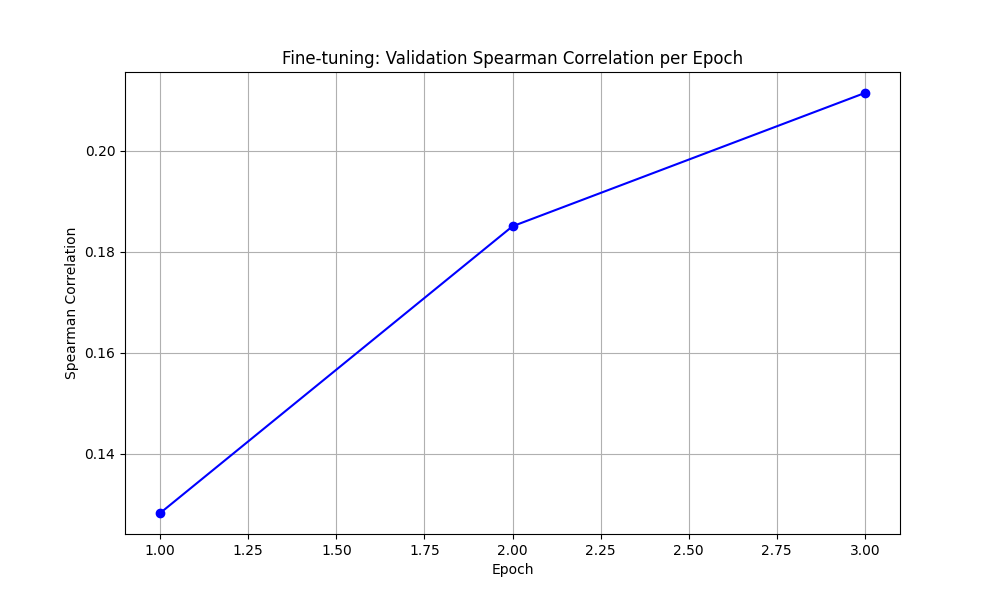

In [ ]:
from IPython.display import Image
if os.path.exists('data/output/metrics/finetuning_curve.png'):
    display(Image(filename='data/output/metrics/finetuning_curve.png'))
else:
    print("Finetuning curve not found. Run finetune_model.py first.")

### Section 6c-6d: Classification Reports for All Three Models
Detailed metrics for the Baseline (RF), Base Multilingual MiniLM, and Proposed Fine-tuned system.

In [ ]:
if os.path.exists('data/output/metrics/full_comparison.csv'):
    full_comp = pd.read_csv('data/output/metrics/full_comparison.csv')
    display(full_comp)
else:
    print("Comparison metrics not found. Run baseline_comparison.py first.")

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline (RF),0.620968,0.589330,0.620968,0.544765
1,Base Multilingual MiniLM,0.500000,0.489201,0.500000,0.494518
2,Proposed Fine-tuned,0.645161,0.614437,0.645161,0.582974


### Section 6e: Learning Curves — RF OOB Error and Fine-tuning Epoch Curve
We analyze the stability and convergence of our models.

Random Forest OOB Error Learning Curve


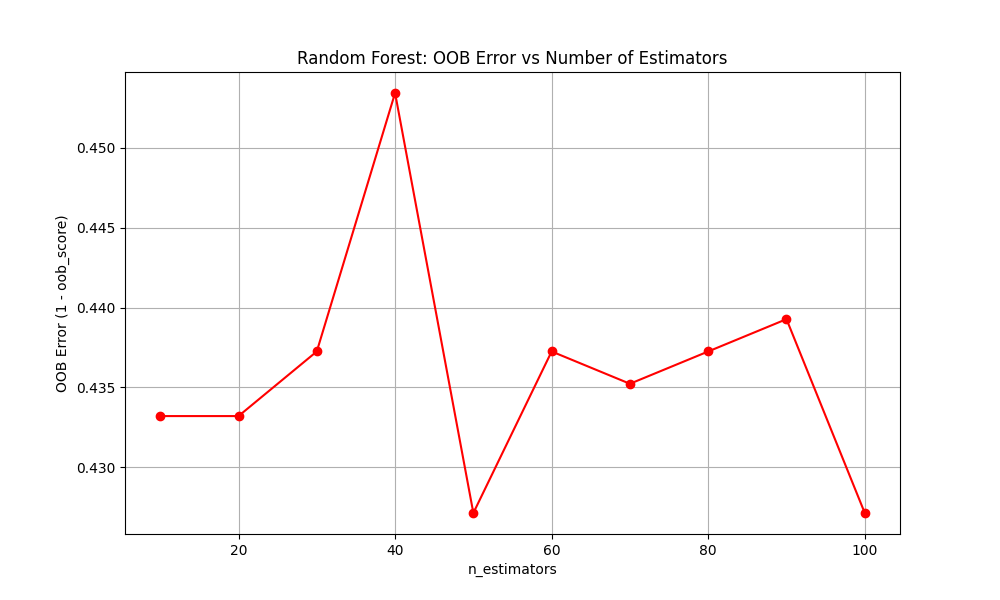


Fine-tuned Model Learning Curve (Spearman Correlation)


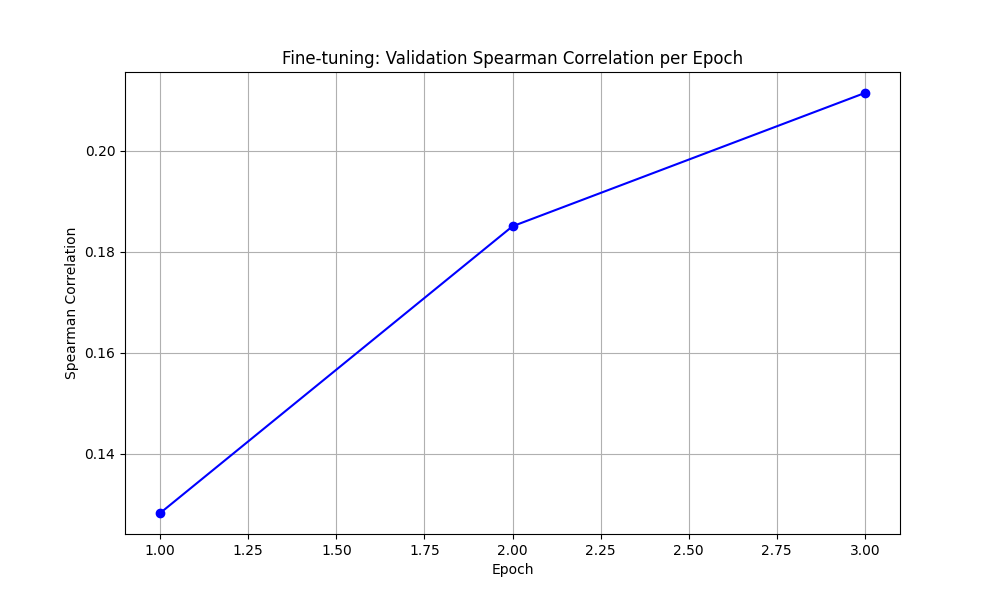

In [ ]:
if os.path.exists('data/output/metrics/rf_learning_curve.png'):
    print("Random Forest OOB Error Learning Curve")
    display(Image(filename='data/output/metrics/rf_learning_curve.png'))
    
if os.path.exists('data/output/metrics/finetuning_curve.png'):
    print("\nFine-tuned Model Learning Curve (Spearman Correlation)")
    display(Image(filename='data/output/metrics/finetuning_curve.png'))

### Section 6f: ROC-AUC, Precision-Recall, Confusion Matrices for All Three Models
Visualizing model accuracy, class-wise separation, and error distribution.

Confusion Matrices for all 3 models


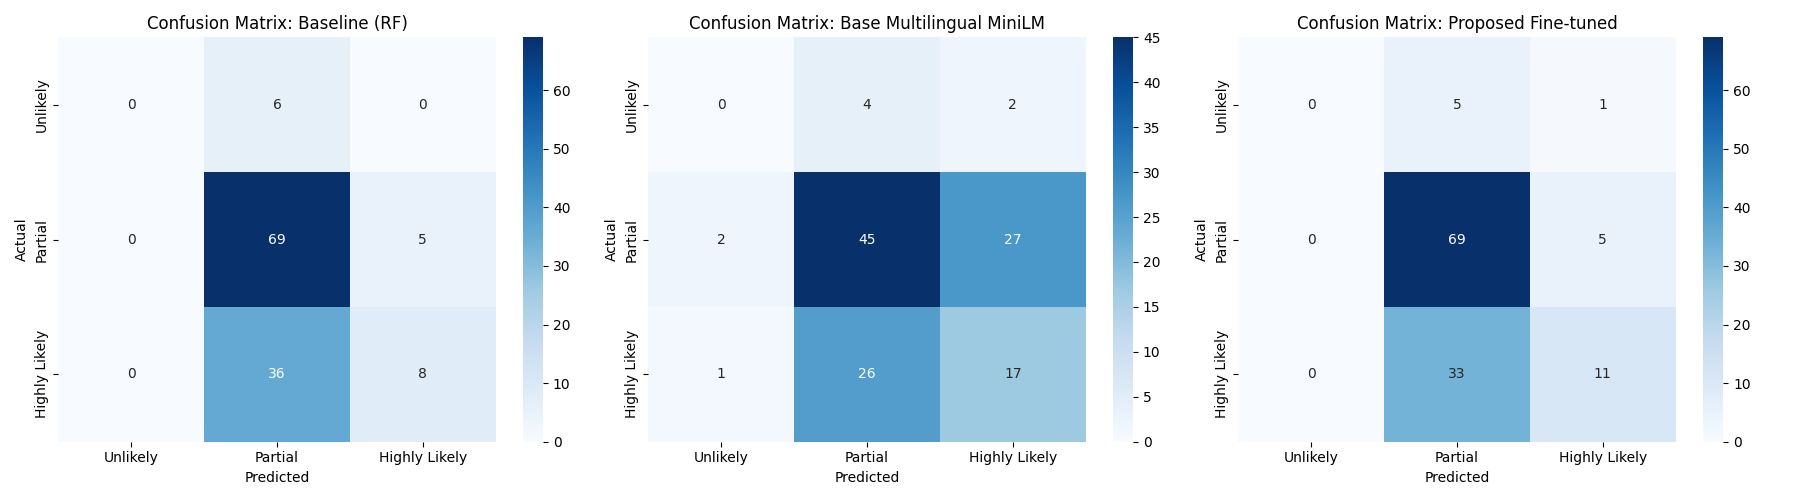


ROC-AUC Curves for Fine-tuned Model


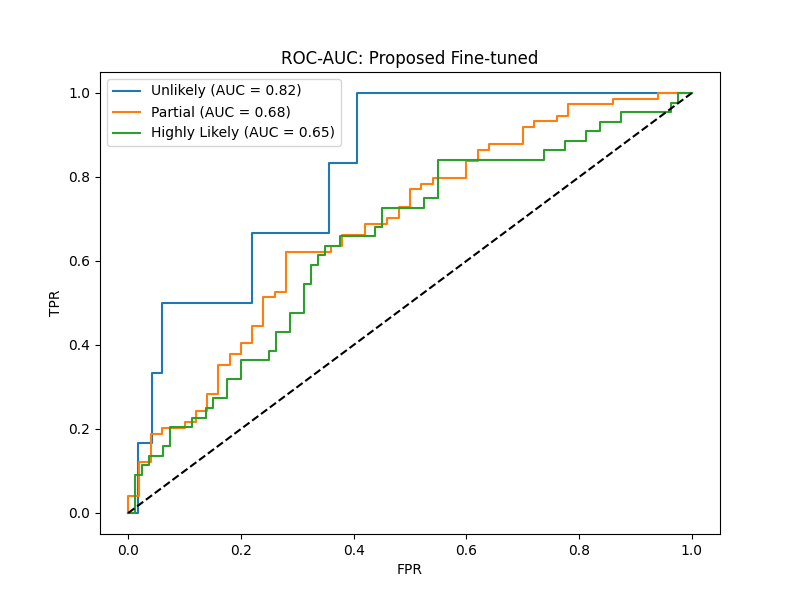

In [ ]:
print("Confusion Matrices for all 3 models")
if os.path.exists('data/output/metrics/confusion_matrices_all3.png'):
    display(Image(filename='data/output/metrics/confusion_matrices_all3.png'))

print("\nROC-AUC Curves for Fine-tuned Model")
if os.path.exists('data/output/metrics/roc_auc_proposed_fine_tuned.png'):
    display(Image(filename='data/output/metrics/roc_auc_proposed_fine_tuned.png'))

### Section 6g: XAI — LIME, Global Feature Importance, Semantic Similarity Heatmap
Explaining model decisions at both a global and local level using state-of-the-art XAI techniques.

Local Word Attribution (LIME)


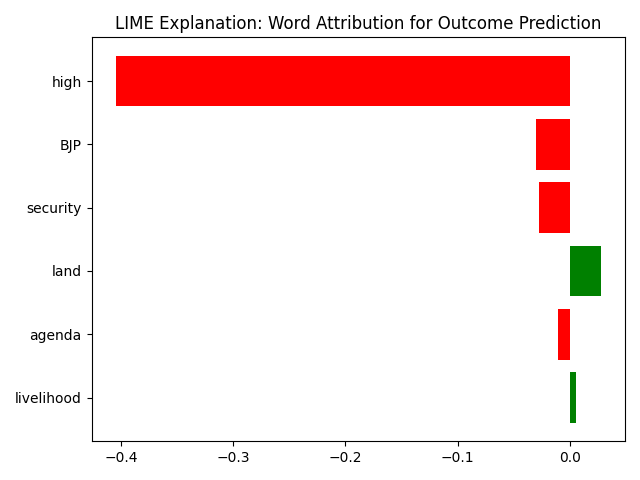


Global Feature Importance (Keywords)


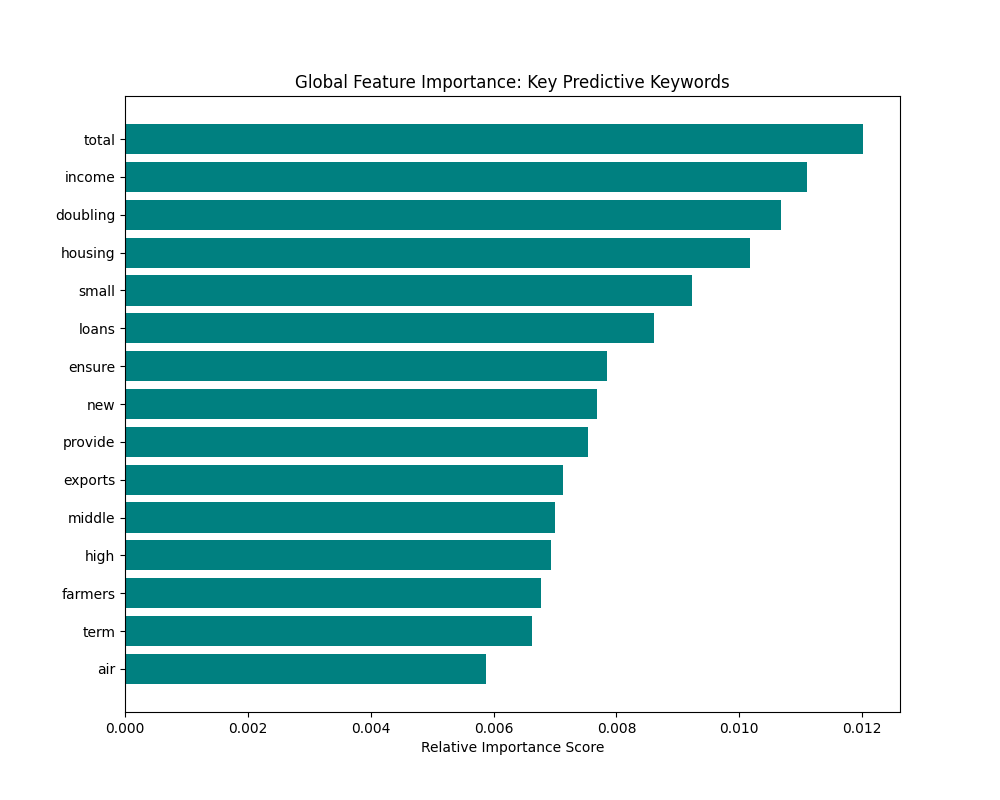


Semantic Similarity Heatmap (RAG Retrieval Consistency)


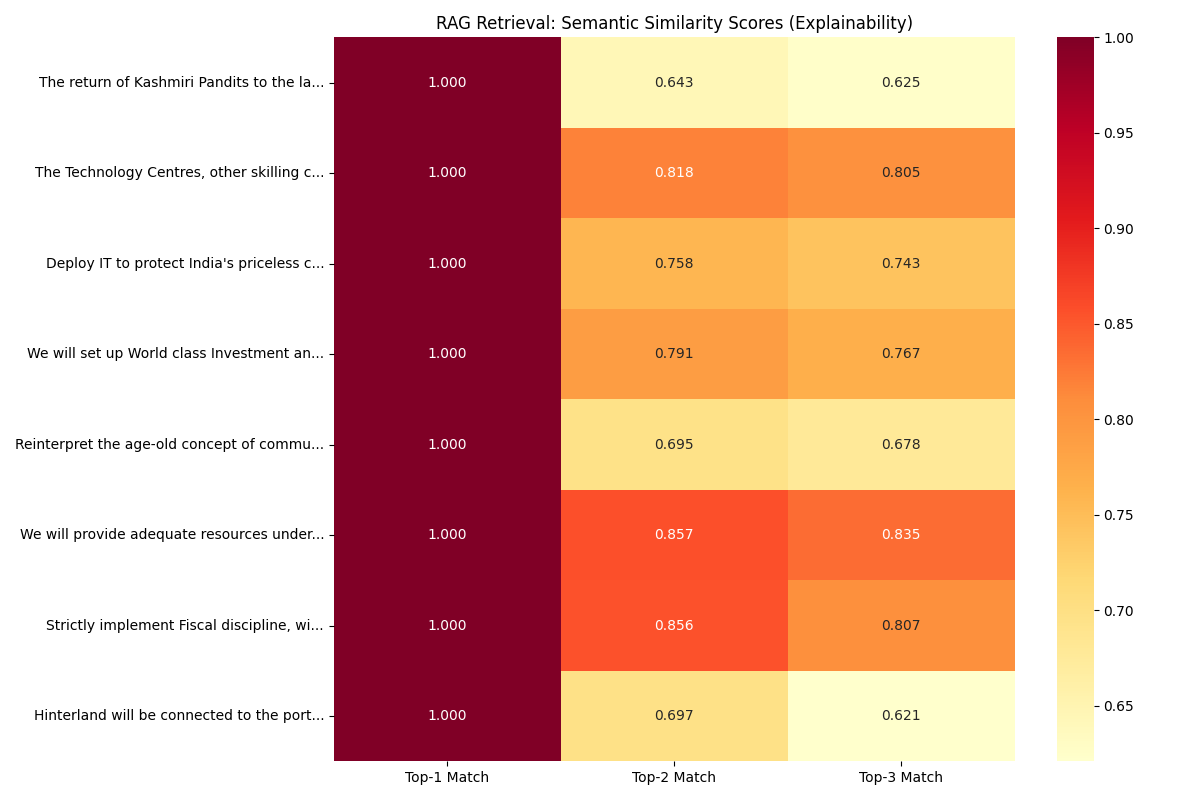

In [ ]:
print("Local Word Attribution (LIME)")
if os.path.exists('data/output/xai/lime_explanation.png'):
    display(Image(filename='data/output/xai/lime_explanation.png'))

print("\nGlobal Feature Importance (Keywords)")
if os.path.exists('data/output/xai/global_feature_importance.png'):
    display(Image(filename='data/output/xai/global_feature_importance.png'))

print("\nSemantic Similarity Heatmap (RAG Retrieval Consistency)")
if os.path.exists('data/output/xai/semantic_similarity_heatmap.png'):
    display(Image(filename='data/output/xai/semantic_similarity_heatmap.png'))

### Section 6i: Final Three-Model Comparison Table and Bar Chart
The final overview comparing accuracy, precision, recall, and F1 across all three implemented models.

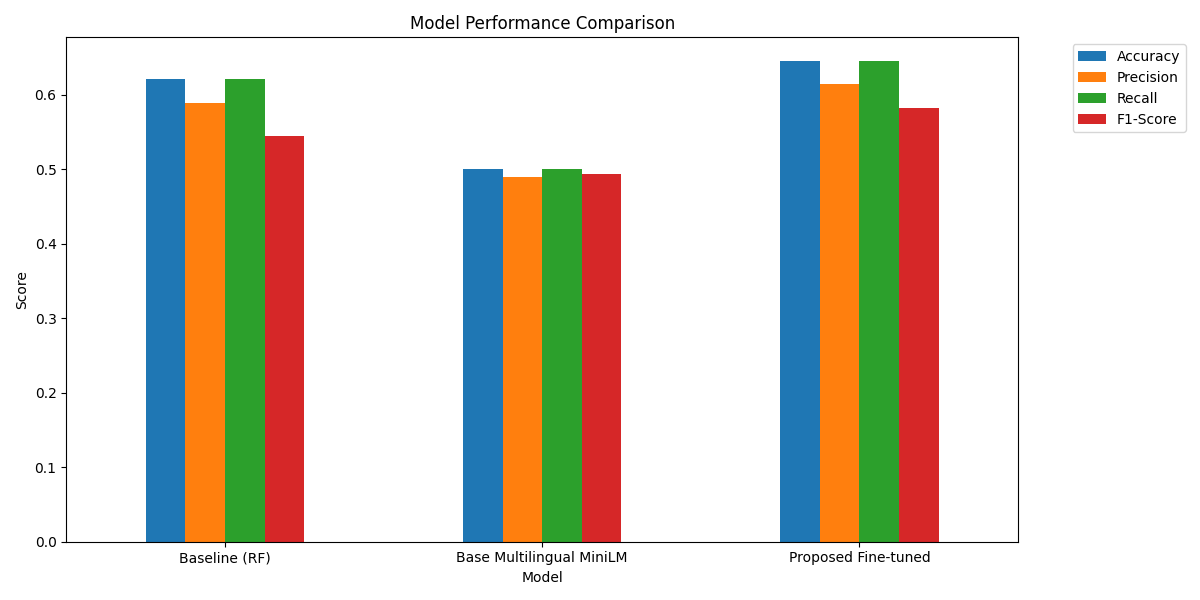

In [ ]:
if os.path.exists('data/output/metrics/model_comparison_bar.png'):
    display(Image(filename='data/output/metrics/model_comparison_bar.png'))